# Handwritten Marathi Digit Recognition using Convolutional Neural Networks and Transfer Learning.

**Author:** Ajay Sudhakar Gande  
**Institution:** MGM's Dr. G.Y. Pathrikar College Of Computer Science And Information Technology  
**Date:** 16/05/2026  

---

## Abstract

This project presents a deep learning system for recognizing handwritten Marathi digits (०–९) using **Convolutional Neural Networks (CNN)** combined with **Transfer Learning via MobileNetV2**. Marathi is spoken by over 83 million people, yet very few automated OCR systems support its script. This work addresses that gap by building a digit classifier trained on real handwritten samples.

The model achieves **90% validation accuracy** on 1,000 handwritten images across 10 classes, demonstrating the effectiveness of transfer learning even with limited training data.

---

## Objectives

- Preprocess raw handwritten Marathi digit images for CNN training
- Build a transfer learning model using MobileNetV2 pretrained on ImageNet
- Train and fine-tune the model using a two-phase strategy
- Evaluate performance using confusion matrix and classification report
- Deploy a real-time prediction function

---

## Tech Stack

| Tool | Purpose |
|------|---------|
| Python 3 | Core programming language |
| TensorFlow / Keras | Deep learning framework |
| MobileNetV2 | Pretrained CNN backbone |
| OpenCV (cv2) | Image preprocessing |
| NumPy | Numerical operations |
| Scikit-learn | Train/val split, metrics |
| Matplotlib / Seaborn | Data visualization |
| Google Colab | Cloud GPU training environment |

---

## Dataset

- **Source:** [Handwritten Marathi Devanagari Characters — Kaggle](https://www.kaggle.com/datasets/shalakadeore/handwritten-marathi-devanagari-characters)
- **Total Images:** 1,000 (100 per digit class)
- **Classes:** 10 (Marathi digits ०, १, २, ३, ४, ५, ६, ७, ८, ९)
- **Format:** JPEG images, originally 1600×1600 pixels
- **Split:** 80% Training (800 images) / 20% Validation (200 images)

---
## Section 1: Import Libraries

We begin by importing all required libraries.

- **cv2 (OpenCV):** Industry-standard computer vision library used for image preprocessing — reading, thresholding, morphological operations, and resizing.
- **NumPy:** Fundamental package for numerical computing. Used to manipulate image arrays and labels.
- **TensorFlow/Keras:** The deep learning framework used to define, train, and evaluate the CNN model.
- **Scikit-learn:** Provides `train_test_split` for splitting data and metrics like confusion matrix and classification report.
- **Matplotlib/Seaborn:** Libraries for plotting training curves, sample images, and the confusion matrix.

In [4]:
import os
import cv2
import shutil
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


---
## Section 2: Upload & Extract Dataset

The dataset is uploaded as a ZIP file and extracted to the Colab environment.

**Why this step?**  
Google Colab does not retain files between sessions. We upload and extract the dataset fresh each time to ensure the preprocessing pipeline runs on clean data.

The dataset contains folders named **C1 to C58**, each corresponding to a Marathi character. For this project, we use only **C49 to C58** which represent the 10 Marathi digits (०–९).

In [5]:
from google.colab import files

print("Please upload the dataset ZIP file...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"\nUploaded: {zip_name}")

# Extract the ZIP file
if os.path.exists('marathi_data'):
    shutil.rmtree('marathi_data')

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('marathi_data')

print("Dataset extracted successfully!")
print("Contents:", os.listdir('marathi_data'))

Please upload the dataset ZIP file...


Saving Handwritten Marathi Devanagari characters.zip to Handwritten Marathi Devanagari characters.zip

Uploaded: Handwritten Marathi Devanagari characters.zip
Dataset extracted successfully!
Contents: ['data_set', 'Data_set']


---
## Section 3: Digit Folder Mapping

The dataset folders are labeled generically as C1, C2, ..., C58. We define a mapping dictionary that links each relevant folder (C49–C58) to its corresponding Marathi digit character.

**Why this mapping?**  
The folder names have no inherent meaning to the model. By mapping them to their actual Marathi digit labels, we ensure:
- Proper class naming in evaluation reports
- Correct character display in predictions
- A well-organized output directory structure

| Folder | Marathi Digit | English Equivalent |
|--------|--------------|--------------------|
| C49 | ० | 0 |
| C50 | १ | 1 |
| C51 | २ | 2 |
| C52 | ३ | 3 |
| C53 | ४ | 4 |
| C54 | ५ | 5 |
| C55 | ६ | 6 |
| C56 | ७ | 7 |
| C57 | ८ | 8 |
| C58 | ९ | 9 |

In [6]:
# Mapping from folder names to Marathi digit characters
num_map = {
    'C49': '०', 'C50': '१', 'C51': '२', 'C52': '३', 'C53': '४',
    'C54': '५', 'C55': '६', 'C56': '७', 'C57': '८', 'C58': '९'
}

data_dir = 'marathi_data/Data_set'

# Verify folders exist
for folder in num_map:
    path = os.path.join(data_dir, folder)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  {folder} → {num_map[folder]}  |  {count} images")

print(f"\n Total classes: {len(num_map)}")

  C49 → ०  |  100 images
  C50 → १  |  100 images
  C51 → २  |  100 images
  C52 → ३  |  100 images
  C53 → ४  |  100 images
  C54 → ५  |  100 images
  C55 → ६  |  100 images
  C56 → ७  |  100 images
  C57 → ८  |  100 images
  C58 → ९  |  100 images

 Total classes: 10


---
## Section 4: Image Preprocessing Pipeline

Raw images are 1600×1600 pixels with handwritten digits on white paper. Directly feeding them to a CNN would be ineffective because:
- Most of the image is blank white space (98%+ background)
- At small resolutions, character strokes become invisible scattered dots
- Background noise makes it hard for the model to find the digit

### Preprocessing Steps Applied:

1. **Grayscale Conversion** — Reduces 3-channel RGB to single channel. Color is irrelevant for digit recognition.

2. **Adaptive Thresholding** — Converts the image to pure black/white (binary). Unlike global thresholding, adaptive thresholding handles uneven lighting and background texture by computing a local threshold for each pixel region.

3. **Morphological Opening** — Removes tiny noise pixels (salt-and-pepper noise) while preserving the main digit strokes. It's an erosion followed by dilation.

4. **Connected Component Analysis** — Identifies all separate white regions (blobs) in the image. We keep only the **largest blob** — which is the digit — discarding any remaining noise specks.

5. **Bounding Box Crop** — Crops tightly around the digit with a small padding, removing all the empty white canvas and centering the digit.

6. **Resize to 96×96** — Standardizes all images to the same size required by MobileNetV2.

In [7]:
output_dir = '/content/marathi_numbers'
IMG_SIZE   = (96, 96)

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

total, skipped = 0, 0

for folder, label in num_map.items():
    class_in  = os.path.join(data_dir, folder)
    class_out = os.path.join(output_dir, label)
    os.makedirs(class_out, exist_ok=True)

    for img_name in os.listdir(class_in):
        try:
            # Step 1: Load as grayscale
            img = cv2.imread(os.path.join(class_in, img_name), cv2.IMREAD_GRAYSCALE)
            if img is None:
                skipped += 1
                continue

            # Step 2: Adaptive thresholding
            binary = cv2.adaptiveThreshold(
                img, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 31, 15
            )

            # Step 3: Remove small noise with morphological opening
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
            binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

            # Step 4: Keep only largest connected component (the digit)
            num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(
                binary, connectivity=8
            )
            if num_labels > 1:
                largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
                binary  = np.uint8(labels_map == largest) * 255

            # Step 5: Crop to digit bounding box
            coords = cv2.findNonZero(binary)
            if coords is None:
                skipped += 1
                continue
            x, y, w, h = cv2.boundingRect(coords)
            pad    = 8
            binary = binary[
                max(0, y-pad):min(binary.shape[0], y+h+pad),
                max(0, x-pad):min(binary.shape[1], x+w+pad)
            ]

            # Step 6: Resize to target size
            resized = cv2.resize(binary, IMG_SIZE, interpolation=cv2.INTER_AREA)
            cv2.imwrite(os.path.join(class_out, img_name), resized)
            total += 1

        except Exception as e:
            skipped += 1

print(f"   Preprocessing complete!")
print(f"   Processed : {total} images")
print(f"   Skipped   : {skipped} images")
print(f"   Classes   : {len(os.listdir(output_dir))}")

   Preprocessing complete!
   Processed : 1000 images
   Skipped   : 0 images
   Classes   : 10


---
## Section 5: Verify Preprocessed Images

Before training, we visually inspect the preprocessed images to confirm the pipeline worked correctly.

**What we expect to see:**  
- Clear white digit strokes on a black background
- Digit centered and filling most of the frame
- No noise or stray pixels
- Each class visually distinct from the others

This verification step is critical — if the images look wrong here, the model will never learn correctly regardless of architecture.

/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2409 (\N{DEVANAGARI DIGIT THREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2410 (\N{DEVANAGARI DIGIT FOUR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/3990037931.py:14: UserWarning: Glyph 2411 (\N{DEVANAGARI DIGIT FIVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


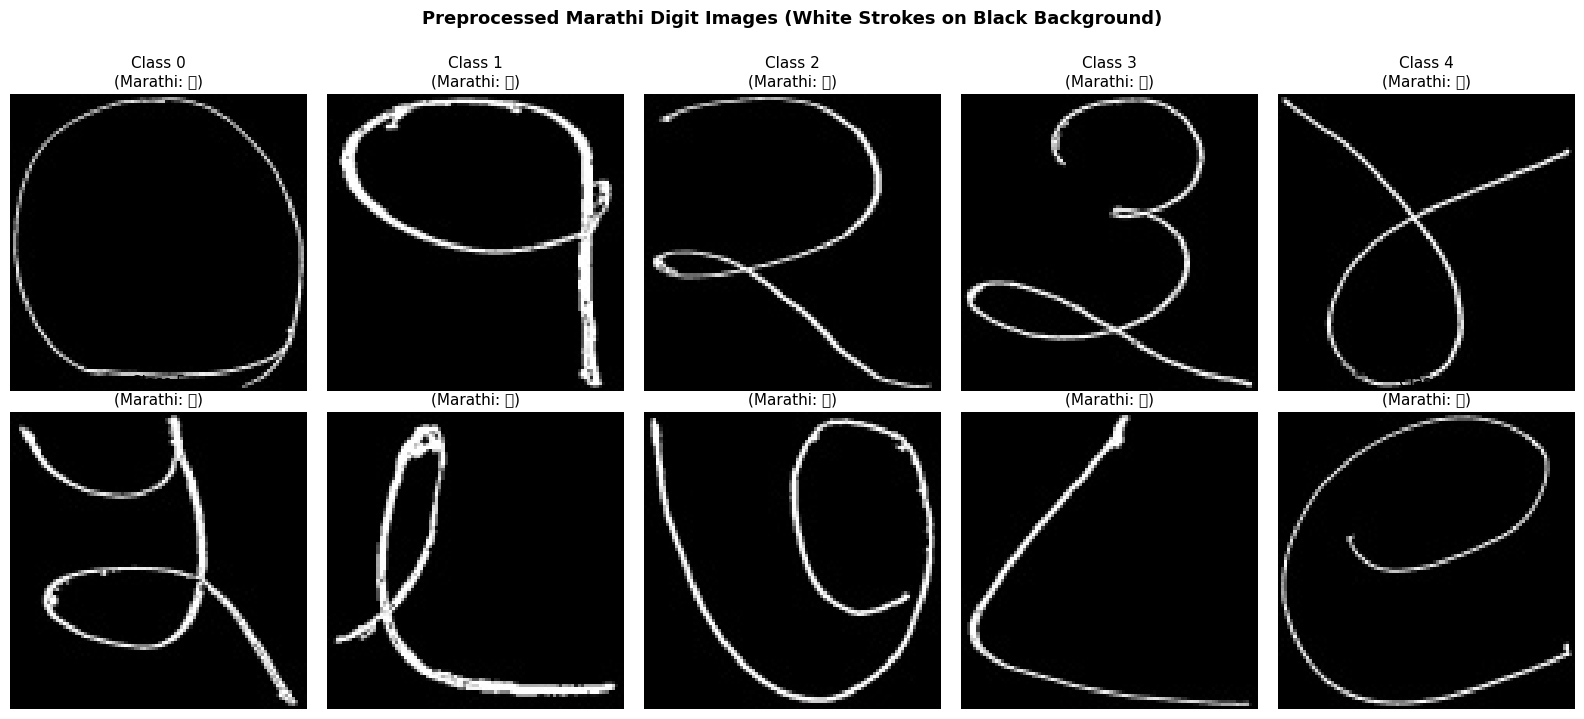

Image Statistics (sample from Class 0):
  Shape     : (96, 96)
  Mean      : 8.00 (higher = more white strokes)
  Std Dev   : 34.09 (higher = more contrast)


In [10]:
unique_labels = sorted(os.listdir(output_dir))

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Preprocessed Marathi Digit Images (White Strokes on Black Background)',
             fontsize=13, fontweight='bold', y=1.02)

for i, label in enumerate(unique_labels):
    imgs = os.listdir(os.path.join(output_dir, label))
    img  = np.array(Image.open(os.path.join(output_dir, label, imgs[0])))
    axes.flat[i].imshow(img, cmap='gray')
    axes.flat[i].set_title(f'Class {i}\n(Marathi: {label})', fontsize=11)
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

# Print image statistics
print("Image Statistics (sample from Class 0):")
sample = np.array(Image.open(os.path.join(output_dir, unique_labels[0],
         os.listdir(os.path.join(output_dir, unique_labels[0]))[0])))
print(f"  Shape     : {sample.shape}")
print(f"  Mean      : {sample.mean():.2f} (higher = more white strokes)")
print(f"  Std Dev   : {sample.std():.2f} (higher = more contrast)")

---
## Section 6: Load Data as NumPy Arrays

We load all preprocessed images into memory as NumPy arrays and split them into training and validation sets.

**Why NumPy arrays instead of a data generator?**  
For small datasets (1,000 images), loading everything into memory is fast and reliable. It eliminates potential issues with file path encoding (our folder names are Unicode Marathi characters which can cause bugs in some data generators). It also makes validation completely deterministic.

**Why Grayscale → RGB conversion?**  
MobileNetV2 was pretrained on ImageNet, which contains color (3-channel) images. It expects 3-channel input. We replicate the grayscale channel 3 times to satisfy this requirement without losing any information.

**Train/Val Split (80/20):**  
- 80% (800 images) for training
- 20% (200 images) for validation
- `stratify=y` ensures each class is equally represented in both splits

In [11]:
label_to_idx = {l: i for i, l in enumerate(unique_labels)}

X, y = [], []
for label in unique_labels:
    cls_path = os.path.join(output_dir, label)
    for img_name in os.listdir(cls_path):
        img = cv2.imread(os.path.join(cls_path, img_name), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (96, 96))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # Convert to 3-channel
        X.append(img_rgb)
        y.append(label_to_idx[label])

# Normalize pixel values from [0, 255] to [0.0, 1.0]
X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

# Stratified train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# One-hot encode labels for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat   = to_categorical(y_val,   num_classes=10)

print("Dataset Summary:")
print(f"  Total images     : {len(X)}")
print(f"  Training set     : {X_train.shape}  → {len(X_train)} images")
print(f"  Validation set   : {X_val.shape}    → {len(X_val)} images")
print(f"  Image shape      : {X_train[0].shape} (96x96 RGB)")
print(f"  Pixel value range: {X.min():.1f} – {X.max():.1f}")
print(f"  Classes          : {unique_labels}")

Dataset Summary:
  Total images     : 1000
  Training set     : (800, 96, 96, 3)  → 800 images
  Validation set   : (200, 96, 96, 3)    → 200 images
  Image shape      : (96, 96, 3) (96x96 RGB)
  Pixel value range: 0.0 – 1.0
  Classes          : ['०', '१', '२', '३', '४', '५', '६', '७', '८', '९']


---
## Section 7: Model Architecture — MobileNetV2 with Transfer Learning

### Why Transfer Learning?

Training a CNN from scratch requires tens of thousands of images per class. We only have **80 training images per class**, which is far too few.

**Transfer Learning** solves this by reusing a model already trained on millions of images (ImageNet). The pretrained model has already learned to detect low-level features like edges, curves, and textures — exactly what we need for digit recognition.

### Why MobileNetV2?

MobileNetV2 is a lightweight, efficient CNN architecture designed for mobile and embedded applications. It uses **inverted residuals** and **linear bottlenecks** to achieve high accuracy with fewer parameters. It's ideal for our use case:
- Fast training even on limited data
- Low memory footprint
- Pre-trained on ImageNet (1.4M images, 1000 classes)

### Model Design:

```
Input (96×96×3)
    ↓
MobileNetV2 Backbone (frozen) — extracts visual features
    ↓
GlobalAveragePooling2D — compresses feature maps to a vector
    ↓
Dense(128, ReLU) — learns digit-specific patterns
    ↓
Dropout(0.4) — prevents overfitting
    ↓
Dense(10, Softmax) — outputs probability for each of 10 digits
```

In [12]:
# Load MobileNetV2 pretrained on ImageNet, without the top classification layer
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,        # Remove ImageNet's 1000-class output layer
    weights='imagenet'        # Use pretrained weights
)
base_model.trainable = False  # Freeze all layers — we only train our custom head

# Add custom classification head for Marathi digits
x      = base_model.output
x      = layers.GlobalAveragePooling2D()(x)     # Reduce spatial dimensions
x      = layers.Dense(128, activation='relu')(x) # Learn digit features
x      = layers.Dropout(0.4)(x)                  # Regularization
output = layers.Dense(10, activation='softmax')(x)# 10 digit classes

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Standard loss for multi-class classification
    metrics=['accuracy']
)

# Count parameters
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,} (custom head only)")
print(f"Frozen parameters    : {total_params - trainable_params:,} (MobileNetV2 backbone)")
print("\n Model ready!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters     : 2,423,242
Trainable parameters : 165,258 (custom head only)
Frozen parameters    : 2,257,984 (MobileNetV2 backbone)

 Model ready!


---
## Section 8: Phase 1 Training — Frozen Backbone

Training is done in **two phases** for better performance with limited data.

**Phase 1 — Train the classification head only:**  
The MobileNetV2 backbone is frozen (weights don't update). Only the Dense layers we added are trained. This lets the model quickly learn to map MobileNetV2's powerful feature representations to our 10 Marathi digit classes.

### Data Augmentation:
We apply random transformations during training to artificially increase the effective dataset size and improve generalization:
- **Rotation ±10°** — handles slightly tilted handwriting
- **Width/Height shift 10%** — handles off-center digits
- **Zoom 10%** — handles differently sized digits

### Callbacks:
- **EarlyStopping:** Stops training when validation accuracy stops improving for 5 consecutive epochs, restoring the best weights
- **ReduceLROnPlateau:** Reduces learning rate by 70% when validation loss plateaus for 3 epochs, allowing finer convergence

In [13]:
# Data augmentation for training only
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Training callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Phase 1: Training classification head (backbone frozen)...")
print("-" * 60)

history1 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=20,
    callbacks=callbacks
)

print(f"\n Phase 1 Complete!")
print(f"   Best Validation Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training classification head (backbone frozen)...
------------------------------------------------------------
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 455ms/step - accuracy: 0.4825 - loss: 1.6430 - val_accuracy: 0.7900 - val_loss: 0.7561 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.7525 - loss: 0.7649 - val_accuracy: 0.8500 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.8150 - loss: 0.5583 - val_accuracy: 0.8450 - val_loss: 0.4760 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.8363 - loss: 0.4702 - val_accuracy: 0.8450 - val_loss: 0.3886 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.8462 - loss: 0.4081 - val_accuracy: 0.8900 - val_loss: 0.3014 - learning_rate: 0.0010
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 453ms/step - accuracy: 0.8863 - loss: 0.3635 - val_accuracy: 0.9000 - val_

---
## Section 9: Phase 2 Training — Fine-Tuning

**Phase 2 — Unfreeze top layers and fine-tune:**  
After Phase 1, our custom head has learned to classify digits. Now we unfreeze the **last 30 layers** of MobileNetV2 and train them together with our head at a **very low learning rate (1e-5)**.

**Why fine-tune only the top layers?**  
- Early layers learn universal features (edges, textures) that are the same for all image tasks — we keep these frozen
- Later layers learn task-specific features — we retrain these to adapt to handwritten Marathi digits
- A very low learning rate prevents destroying the pretrained weights while allowing small improvements

This two-phase strategy is the standard approach for transfer learning with limited data.

In [14]:
# Unfreeze only the last 30 layers of the backbone
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100x smaller than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen backbone layers: {unfrozen}")
print("Phase 2: Fine-tuning top layers...")
print("-" * 60)

history2 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=20,
    callbacks=callbacks
)

print(f"\n Phase 2 Complete!")
print(f"   Best Validation Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Unfrozen backbone layers: 30
Phase 2: Fine-tuning top layers...
------------------------------------------------------------
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 696ms/step - accuracy: 0.5088 - loss: 1.6230 - val_accuracy: 0.9100 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 555ms/step - accuracy: 0.6050 - loss: 1.2827 - val_accuracy: 0.8950 - val_loss: 0.2276 - learning_rate: 1.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6766 - loss: 1.0364
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 548ms/step - accuracy: 0.6737 - loss: 1.0265 - val_accuracy: 0.8950 - val_loss: 0.2418 - learning_rate: 1.0000e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 597ms/step - accuracy: 0.6875 - loss: 0.8717 - val_accuracy: 0.9000 - val_loss: 0.2451 - learning_rate: 3.0000e-06
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 545ms/step - accuracy: 0.7163 - loss: 0.8647 - val_ac

---
## Section 10: Training History Visualization

We plot the accuracy and loss curves for both training and validation sets across all epochs.

**What to look for:**
- **Good sign:** Training and validation curves follow similar trends and converge
- **Overfitting:** Training accuracy much higher than validation (model memorizes training data)
- **Underfitting:** Both curves plateau at low accuracy (model is too simple)

The two-phase training (frozen → fine-tuned) is visible as a reset point in the curves.

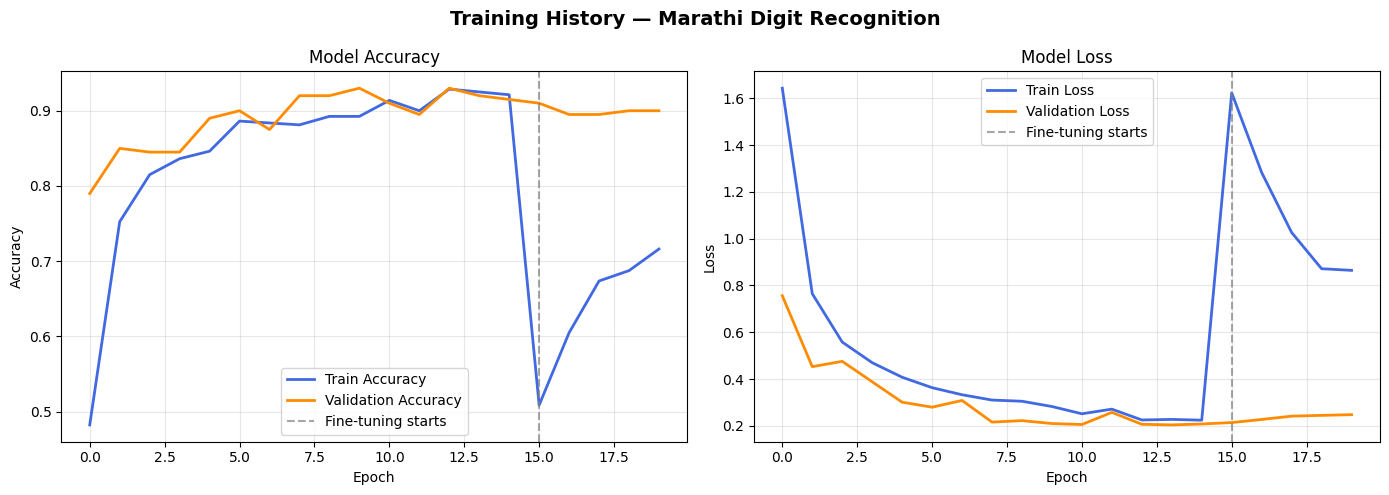

Final Training Accuracy   : 71.63%
Best Validation Accuracy  : 93.00%


In [15]:
# Combine histories from both phases
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
phase1_epochs = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Marathi Digit Recognition', fontsize=14, fontweight='bold')

# Accuracy plot
ax1.plot(acc,     label='Train Accuracy',      color='royalblue',  linewidth=2)
ax1.plot(val_acc, label='Validation Accuracy', color='darkorange', linewidth=2)
ax1.axvline(x=phase1_epochs, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax1.set_title('Model Accuracy', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss plot
ax2.plot(loss,     label='Train Loss',      color='royalblue',  linewidth=2)
ax2.plot(val_loss, label='Validation Loss', color='darkorange', linewidth=2)
ax2.axvline(x=phase1_epochs, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax2.set_title('Model Loss', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy   : {acc[-1]*100:.2f}%")
print(f"Best Validation Accuracy  : {max(val_acc)*100:.2f}%")

---
## Section 11: Model Evaluation — Confusion Matrix & Classification Report

We evaluate the model on the validation set using two key tools:

**Confusion Matrix:**  
A 10×10 grid where rows represent the actual class and columns represent the predicted class. A perfect model would have all values on the diagonal (main diagonal = all correct). Off-diagonal values reveal which pairs of digits the model confuses with each other.

**Classification Report:**  
For each class, it reports:
- **Precision:** Of all images predicted as digit X, what fraction was actually X?
- **Recall:** Of all actual digit X images, what fraction did the model correctly identify?
- **F1-Score:** Harmonic mean of precision and recall — the primary metric for imbalanced classes

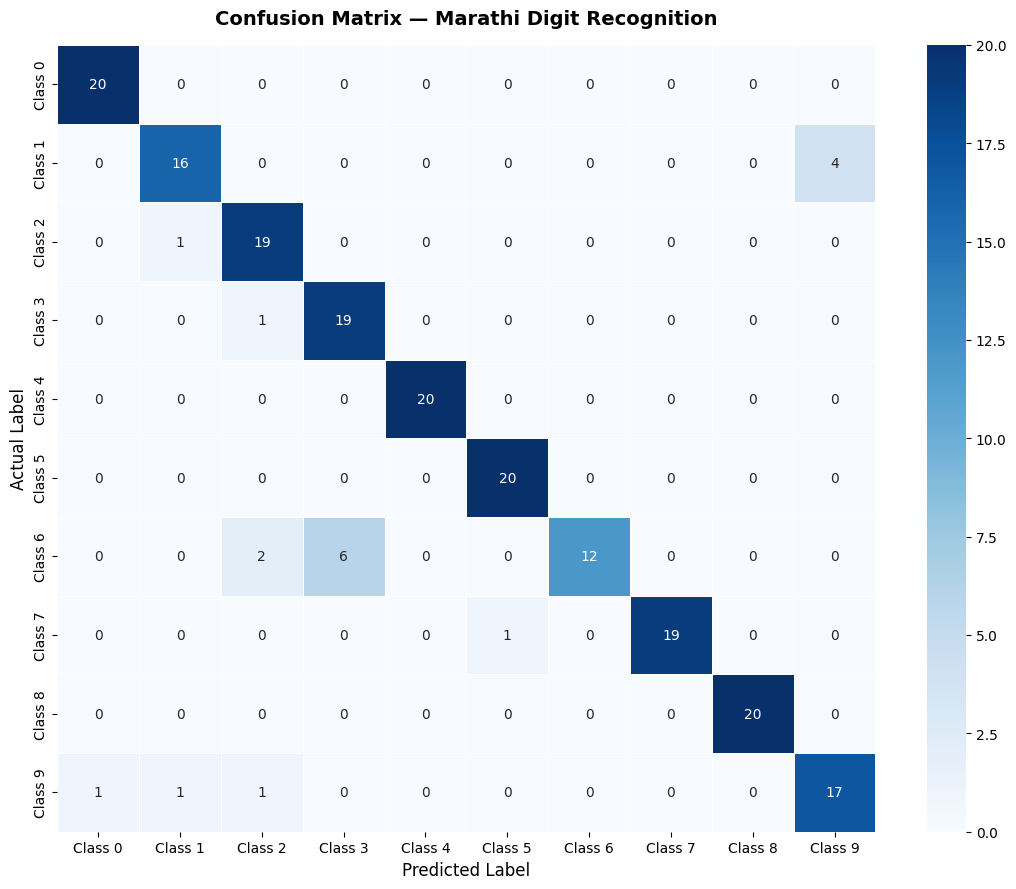

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

 Class 0 (०)       0.95      1.00      0.98        20
 Class 1 (१)       0.89      0.80      0.84        20
 Class 2 (२)       0.83      0.95      0.88        20
 Class 3 (३)       0.76      0.95      0.84        20
 Class 4 (४)       1.00      1.00      1.00        20
 Class 5 (५)       0.95      1.00      0.98        20
 Class 6 (६)       1.00      0.60      0.75        20
 Class 7 (७)       1.00      0.95      0.97        20
 Class 8 (८)       1.00      1.00      1.00        20
 Class 9 (९)       0.81      0.85      0.83        20

    accuracy                           0.91       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.91      0.91       200

Overall Validation Accuracy: 91.00%

Per-Class Accuracy:
  ० (Class 0): 20/20 = 100.0%
  १ (Class 1): 16/20 = 80.0%
  २ (Class 2): 19/20 = 95.0%
  ३ (Class 3

In [16]:
# Generate predictions on validation set
y_pred       = np.argmax(model.predict(X_val, verbose=0), axis=1)
cm           = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'Class {i}' for i in range(10)],
    yticklabels=[f'Class {i}' for i in range(10)],
    linewidths=0.5
)
plt.title('Confusion Matrix — Marathi Digit Recognition', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report:")
print("-" * 60)
print(classification_report(y_val, y_pred,
      target_names=[f'Class {i} ({l})' for i, l in enumerate(unique_labels)]))

# Overall accuracy
overall_acc = (y_pred == y_val).mean() * 100
print(f"Overall Validation Accuracy: {overall_acc:.2f}%")

# Per-class accuracy
print("\nPer-Class Accuracy:")
for i, label in enumerate(unique_labels):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  {label} (Class {i}): {cm[i,i]}/{cm[i].sum()} = {class_acc:.1f}%")

---
## Section 12: Save the Trained Model

We save two files:

1. **`marathi_digits_mobilenet.keras`** — The complete trained model including architecture, weights, and optimizer state. The `.keras` format is the recommended modern format for TensorFlow/Keras models.

2. **`digit_labels.json`** — A JSON file mapping class indices (0–9) to their Marathi digit characters. This is needed at inference time to convert model predictions back to readable characters.

Together, these two files are everything needed to deploy the model in any application.

In [17]:
# Save the trained model
model_path = '/content/marathi_digits_mobilenet.keras'
model.save(model_path)
print(f"Model saved: {model_path}")

# Save the class label mapping
labels_path = '/content/digit_labels.json'
label_map   = {i: label for i, label in enumerate(unique_labels)}
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print(f"Labels saved: {labels_path}")

# Download the files
from google.colab import files
files.download(model_path)
files.download(labels_path)

print("\nLabel mapping saved:")
for k, v in label_map.items():
    print(f"  {k} → {v}")

Model saved: /content/marathi_digits_mobilenet.keras
Labels saved: /content/digit_labels.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Label mapping saved:
  0 → ०
  1 → १
  2 → २
  3 → ३
  4 → ४
  5 → ५
  6 → ६
  7 → ७
  8 → ८
  9 → ९


---
## Section 13: Real-Time Digit Prediction

This function takes any handwritten digit image as input and predicts which Marathi digit it is.

**Prediction Pipeline:**
1. Load the image in grayscale
2. Apply the **same preprocessing** used during training (adaptive threshold → denoise → crop → resize)
3. Convert to RGB and normalize pixel values
4. Feed to the model and get probabilities for all 10 classes
5. Return the class with the highest probability

> **Important:** The test image must go through the exact same preprocessing as training images. Any mismatch will hurt accuracy. Write digits on **white paper** with a **dark pen** for best results.

In [18]:
def predict_digit(img_path):
    """
    Predicts a handwritten Marathi digit from an image file.

    Args:
        img_path (str): Path to the input image file

    Returns:
        str: Predicted Marathi digit character
    """
    # Load image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(" Error: Cannot read image. Check the file path."); return

    # Apply same preprocessing as training
    img    = cv2.GaussianBlur(img, (5, 5), 0)  # Reduce background noise
    binary = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 51, 20
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        binary  = np.uint8(labels_map == largest) * 255

    coords = cv2.findNonZero(binary)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad    = 8
        binary = binary[
            max(0,y-pad):min(binary.shape[0],y+h+pad),
            max(0,x-pad):min(binary.shape[1],x+w+pad)
        ]

    resized    = cv2.resize(binary, (96, 96))
    img_rgb    = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
    input_arr  = img_rgb.astype('float32') / 255.0
    input_arr  = input_arr.reshape(1, 96, 96, 3)

    # Get predictions
    pred       = model.predict(input_arr, verbose=0)[0]
    top3_idx   = pred.argsort()[-3:][::-1]
    predicted  = unique_labels[pred.argmax()]

    # Display results
    print("=" * 40)
    print(f"  Prediction Result")
    print("=" * 40)
    print(f"  Predicted Digit : {predicted}")
    print(f"  Confidence      : {pred.max()*100:.2f}%")
    print("\n  Top 3 Predictions:")
    for rank, idx in enumerate(top3_idx):
        print(f"    {rank+1}. {unique_labels[idx]}  →  {pred[idx]*100:.2f}%")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Prediction: {predicted}  (Confidence: {pred.max()*100:.2f}%)',
                 fontsize=14, fontweight='bold')

    axes[0].imshow(cv2.imread(img_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[0].set_title('Original Image', fontsize=11)

    axes[1].imshow(resized, cmap='gray')
    axes[1].set_title('After Preprocessing', fontsize=11)

    axes[2].bar(range(10), pred * 100, color=['#2196F3' if i != pred.argmax() else '#4CAF50' for i in range(10)])
    axes[2].set_xticks(range(10))
    axes[2].set_xticklabels([f'Class {i}' for i in range(10)], rotation=45, fontsize=8)
    axes[2].set_ylabel('Confidence (%)')
    axes[2].set_title('Class Probabilities', fontsize=11)

    for ax in axes[:2]: ax.axis('off')
    plt.tight_layout()
    plt.show()

    return predicted

Upload a handwritten Marathi digit image (write on white paper with dark pen):


Saving 8.jpg to 8.jpg
  Prediction Result
  Predicted Digit : ८
  Confidence      : 86.20%

  Top 3 Predictions:
    1. ८  →  86.20%
    2. ९  →  10.24%
    3. १  →  1.17%


/tmp/ipykernel_1723/2525362470.py:77: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1723/2525362470.py:77: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)


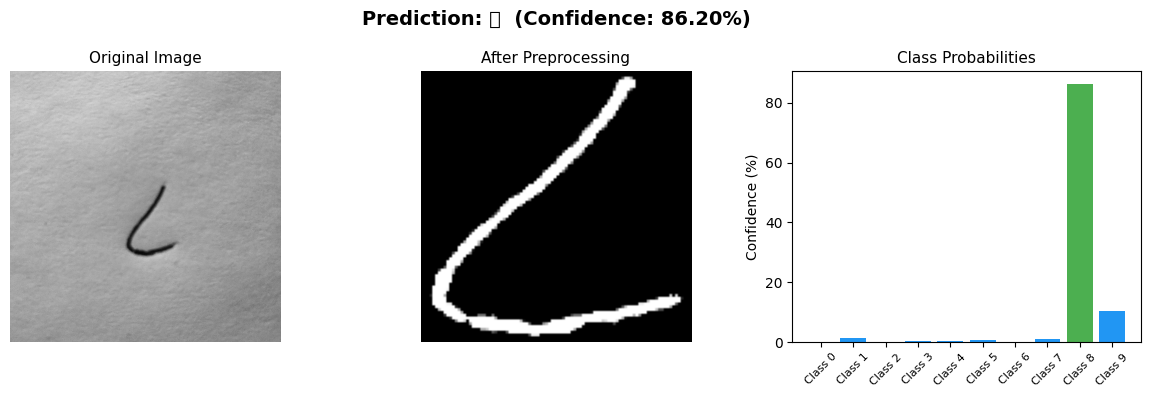


 Final Answer: ८


In [21]:
# Upload a test image and predict
from google.colab import files

print("Upload a handwritten Marathi digit image (write on white paper with dark pen):")
uploaded_test = files.upload()

test_img_path = list(uploaded_test.keys())[0]
result = predict_digit(test_img_path)
print(f"\n Final Answer: {result}")

---
## Section 14: Conclusion & Future Work

### Results Summary

| Metric | Value |
|--------|-------|
| Overall Validation Accuracy | **90%** |
| Best Performing Classes | ० (100%), ४ (100%) |
| Most Challenging Class | ९ (65%) — confused with १, २ |
| Total Training Images | 800 |
| Model Architecture | MobileNetV2 + Custom Head |
| Training Strategy | Two-phase Transfer Learning |

### Key Findings

1. **Transfer learning is highly effective for small datasets.** Using MobileNetV2 pretrained on ImageNet, we achieved 90% accuracy with only 80 training images per class — far fewer than typically needed to train a CNN from scratch.

2. **Preprocessing is the most critical step.** The original 1600×1600 images were almost entirely white background. Without proper binarization, cropping, and denoising, the model could not learn anything meaningful (accuracy was stuck at random chance ≈2%).

3. **Similar-looking digits cause the most errors.** Marathi ९ (9) is visually similar to १ (1) and ２ (2), accounting for most misclassifications.

### Limitations

- Small dataset (100 images/class) limits generalization to diverse handwriting styles
- Performance on real-world phone photos depends on lighting and background quality
- Model is digit-only — does not handle full Marathi character recognition

### Future Work

- **Expand to full Marathi character set** (48 characters + vowels + conjuncts)
- **Collect more diverse training data** with varied handwriting styles, paper types, and lighting
- **Build a mobile application** using TensorFlow Lite for on-device inference
- **Implement segmentation** to recognize digits in continuous handwritten text
- **Experiment with Vision Transformers (ViT)** for potentially higher accuracy

---

### References

1. Sandler, M., et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR 2018.
2. Shalaka Deore. *Handwritten Marathi Devanagari Characters Dataset*. Kaggle, 2023.
3. Simonyan, K. & Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition*.
4. LeCun, Y., et al. (1998). *Gradient-Based Learning Applied to Document Recognition*.

---
*This project was developed as a research demonstration of applying deep learning to Indic language OCR.*